In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [4]:
# mcds_path = './data/Arab10_All_mcds.mcds'
mcds_path = '../All_mcds.mcds'
rna_path = '../Arab6_RNA_normalized_data.csv'
meta_path ='../data/Arab6_cells_and_clusters.csv'

In [5]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path,index_col = 0).T
meta = pd.read_csv(meta_path)
sig_gene = pd.read_csv('../../clusters/sig.genes.txt', header = None)
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')
# meta['Cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})

In [14]:
ben_gene = pd.read_csv('../../clusters/williams_genes.JW.txt', header = None)
ben_gene

,0
0,AT1G01020
1,AT1G04410
2,AT1G04650
3,AT1G05570
4,AT1G05620
...,...
576,AT5G65280
577,AT5G66530
578,AT5G66520
579,AT5G67340


In [7]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [8]:
filtered_columns = [col for col in mCGN_mc.columns if 'ATM' not in col and 'ATC' not in col and 'cluster' not in col]
mCGN_mc['cluster'] = meta['Cluster']
mCGN_mc_by_cluster = mCGN_mc.groupby('cluster').sum()[filtered_columns]
mCGN_mc_by_cluster
mCGN_cov['cluster'] = meta['Cluster']
mCGN_cov_by_cluster = mCGN_cov.groupby('cluster').sum()[filtered_columns]

In [9]:
mCGN_frac_by_cluster = mCGN_mc_by_cluster.div(mCGN_cov_by_cluster).fillna(0)
mCGN_frac_by_cluster

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.025490,0.069221,0.000000,0.004898,0.597558,0.068908,0.507042,0.133719,0.008969,0.119029,...,0.097147,0.005017,0.003882,0.146733,0.006708,0.000000,0.079179,0.005377,0.006361,0.003486
1.0,0.028993,0.057388,0.009804,0.006477,0.603006,0.060901,0.518519,0.131061,0.004748,0.114884,...,0.101418,0.002966,0.004318,0.153587,0.007095,0.000000,0.071560,0.006052,0.010526,0.002725
2.0,0.032244,0.058621,0.027027,0.004906,0.621651,0.092033,0.493976,0.131535,0.007092,0.120173,...,0.086188,0.002346,0.009202,0.149219,0.007316,0.000000,0.080207,0.006472,0.023392,0.003690
3.0,0.034498,0.048050,0.000000,0.005613,0.614978,0.083645,0.582278,0.131068,0.002392,0.128700,...,0.110066,0.005741,0.005059,0.126192,0.006215,0.000000,0.077694,0.003205,0.019391,0.005968
4.0,0.025919,0.064257,0.000000,0.004799,0.604484,0.062181,0.533333,0.130783,0.006623,0.135154,...,0.104617,0.006182,0.001983,0.121053,0.007403,0.000000,0.069497,0.002721,0.003145,0.010604
5.0,0.021434,0.056250,0.000000,0.002647,0.607248,0.067816,0.535354,0.122752,0.003425,0.135616,...,0.105356,0.004134,0.002385,0.139180,0.002356,0.000000,0.082990,0.005559,0.018657,0.011905
6.0,0.035757,0.059511,0.000000,0.002796,0.613012,0.065217,0.514286,0.135235,0.000000,0.125036,...,0.080844,0.007987,0.007014,0.135812,0.002155,0.030769,0.075269,0.000725,0.004202,0.000000
7.0,0.026185,0.061662,0.000000,0.005244,0.648350,0.103922,0.523810,0.120798,0.005102,0.124211,...,0.134703,0.007481,0.006369,0.128773,0.004030,0.000000,0.073805,0.003367,0.012121,0.000000
8.0,0.042767,0.063752,0.000000,0.004905,0.633127,0.048346,0.339623,0.152623,0.015504,0.118291,...,0.089888,0.003158,0.005464,0.135767,0.005678,0.000000,0.085005,0.005476,0.000000,0.003205


In [10]:
#filter by methylation mean
mCGN_frac_by_cluster = mCGN_frac_by_cluster.loc[:,mCGN_frac_by_cluster.mean(axis=0)>0.03]

In [11]:
mCGN_frac_by_cluster

gene,AT1G01020,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.069221,0.597558,0.068908,0.507042,0.133719,0.119029,0.125474,0.294083,0.066113,0.053755,...,0.207325,0.040118,0.035840,0.117082,0.297148,0.291778,0.226614,0.097147,0.146733,0.079179
1.0,0.057388,0.603006,0.060901,0.518519,0.131061,0.114884,0.105580,0.284311,0.059720,0.042728,...,0.199668,0.036056,0.035247,0.120266,0.275310,0.299264,0.220784,0.101418,0.153587,0.071560
2.0,0.058621,0.621651,0.092033,0.493976,0.131535,0.120173,0.137964,0.304712,0.088514,0.037474,...,0.216643,0.044677,0.034151,0.126146,0.329412,0.320830,0.219957,0.086188,0.149219,0.080207
3.0,0.048050,0.614978,0.083645,0.582278,0.131068,0.128700,0.122354,0.296836,0.066581,0.065938,...,0.094606,0.047649,0.041115,0.122634,0.323377,0.264831,0.223773,0.110066,0.126192,0.077694
4.0,0.064257,0.604484,0.062181,0.533333,0.130783,0.135154,0.133706,0.317882,0.090328,0.047130,...,0.228042,0.053190,0.037139,0.121908,0.303265,0.302717,0.217951,0.104617,0.121053,0.069497
5.0,0.056250,0.607248,0.067816,0.535354,0.122752,0.135616,0.142302,0.311032,0.068723,0.046402,...,0.116910,0.035667,0.032719,0.132767,0.315268,0.278857,0.245702,0.105356,0.139180,0.082990
6.0,0.059511,0.613012,0.065217,0.514286,0.135235,0.125036,0.140368,0.300723,0.072381,0.044242,...,0.188767,0.038814,0.029083,0.126939,0.328006,0.263374,0.214307,0.080844,0.135812,0.075269
7.0,0.061662,0.648350,0.103922,0.523810,0.120798,0.124211,0.104567,0.251309,0.076302,0.043810,...,0.304369,0.044271,0.050479,0.108457,0.345022,0.304727,0.231698,0.134703,0.128773,0.073805
8.0,0.063752,0.633127,0.048346,0.339623,0.152623,0.118291,0.111975,0.313628,0.075560,0.057841,...,0.175227,0.034000,0.036342,0.119257,0.319940,0.283767,0.224671,0.089888,0.135767,0.085005


In [15]:
# Create a list of significant genes
sig_gene_list = ben_gene[0].tolist()

# Subset the original DataFrame to include only the columns for the significant genes
sig_gene_overlap_df = mCGN_frac_by_cluster.loc[:, mCGN_frac_by_cluster.columns.isin(sig_gene_list)]

sig_gene_overlap_df

gene,AT1G01020,AT1G04410,AT1G04650,AT1G05570,AT1G05620,AT1G06560,AT1G07010,AT1G04547,AT1G07040,AT1G07380,...,AT5G60600,AT5G60900,AT5G61070,AT5G61580,AT5G61980,AT5G62570,AT5G66530,AT5G66520,AT5G67340,AT5G67385
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.069221,0.177999,0.099666,0.288734,0.056082,0.238174,0.131922,0.025000,0.091799,0.099091,...,0.278620,0.044935,0.144683,0.191226,0.238214,0.157205,0.127190,0.213660,0.173586,0.207325
1.0,0.057388,0.177588,0.102112,0.283930,0.057386,0.235660,0.133391,0.053950,0.088990,0.116832,...,0.293011,0.035636,0.144365,0.186587,0.232717,0.140146,0.132548,0.216381,0.166137,0.199668
2.0,0.058621,0.197060,0.124038,0.313774,0.063785,0.247116,0.141960,0.060150,0.087063,0.114816,...,0.284967,0.048201,0.226791,0.219052,0.282028,0.147806,0.103007,0.169639,0.171446,0.216643
3.0,0.048050,0.174385,0.135100,0.315093,0.019740,0.252913,0.153111,0.032787,0.082074,0.148896,...,0.308941,0.037915,0.228930,0.194734,0.271119,0.131505,0.204020,0.331519,0.215736,0.094606
4.0,0.064257,0.182081,0.110221,0.297691,0.064257,0.249793,0.150778,0.051064,0.103152,0.102075,...,0.277904,0.038809,0.172115,0.171024,0.257340,0.157257,0.116271,0.190386,0.182915,0.228042
5.0,0.056250,0.189757,0.121485,0.322095,0.015630,0.253562,0.148210,0.044693,0.075587,0.133303,...,0.300683,0.038417,0.220386,0.219769,0.277432,0.154301,0.198318,0.350337,0.235652,0.116910
6.0,0.059511,0.172803,0.101355,0.310194,0.069429,0.240568,0.176357,0.101852,0.086619,0.156434,...,0.290772,0.036312,0.210273,0.249168,0.256191,0.134241,0.149929,0.256203,0.171282,0.188767
7.0,0.061662,0.190237,0.149647,0.299322,0.050906,0.263714,0.139511,0.046512,0.089164,0.249648,...,0.302781,0.040266,0.219289,0.218731,0.290364,0.116438,0.219836,0.360665,0.176656,0.304369
8.0,0.063752,0.209048,0.097446,0.335963,0.059736,0.277487,0.129371,0.014706,0.080803,0.123871,...,0.288546,0.045035,0.200813,0.226804,0.257940,0.153137,0.148741,0.241040,0.140805,0.175227


In [16]:
shared_frac = sig_gene_overlap_df.shape[1]/len(ben_gene)
shared_frac 

0.8072289156626506

In [18]:
# corr analysis

In [19]:
rna_matrix['Cluster'] = meta['Cluster']
# rna_matrix
rna_by_cluster = rna_matrix.groupby('Cluster').mean()
rna_by_cluster

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [21]:
corr_values = sig_gene_overlap_df.corrwith(rna_by_cluster, axis =0).dropna()
corr_values

AT1G01020    0.120394
AT1G04410   -0.250652
AT1G04650   -0.604650
AT1G05570    0.103788
AT1G05620   -0.431743
               ...   
AT5G61980    0.070973
AT5G62570    0.031657
AT5G66530   -0.437655
AT5G67340   -0.310226
AT5G67385   -0.408422
Length: 457, dtype: float64

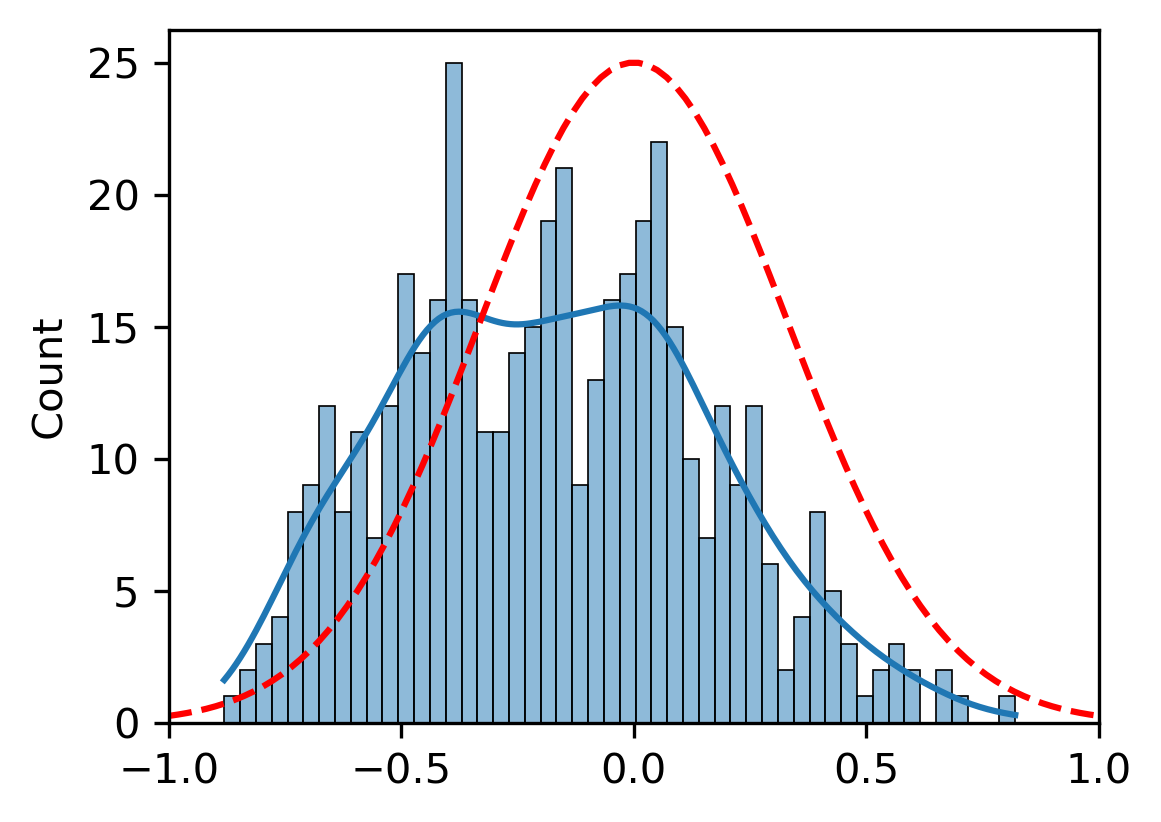

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming corr_values is a numpy array or pandas Series with your correlation values
# corr_values = ...

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_values, ax=ax, kde=True, bins=50, label='corr')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# # Add legend
# ax.legend()

# Show or save the figure
fig.savefig(f'./figures/0517_BW_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


In [24]:
df = sig_gene_overlap_df
# Get the column names
columns = list(df.columns)

# Shuffle the columns
shuffled_columns = np.random.permutation(columns)

# Create a new DataFrame with shuffled columns while maintaining the order of values
shuffled_df = pd.DataFrame({columns[i]: df[shuffled_columns[i]].values for i in range(len(columns))})

# Print shuffled DataFrame
print("\nShuffled DataFrame:")
shuffled_df


Shuffled DataFrame:


,AT1G01020,AT1G04410,AT1G04650,AT1G05570,AT1G05620,AT1G06560,AT1G07010,AT1G04547,AT1G07040,AT1G07380,...,AT5G60600,AT5G60900,AT5G61070,AT5G61580,AT5G61980,AT5G62570,AT5G66530,AT5G66520,AT5G67340,AT5G67385
0,0.151832,0.352848,0.132719,0.055048,0.122489,0.058103,0.121985,0.381090,0.283083,0.080222,...,0.087949,0.172270,0.162100,0.057037,0.376514,0.177999,0.071066,0.215768,0.058353,0.396375
1,0.152097,0.342149,0.146395,0.052226,0.135322,0.055967,0.106810,0.364477,0.280817,0.078538,...,0.094793,0.162208,0.184236,0.050214,0.374149,0.177588,0.078652,0.216472,0.057591,0.347504
2,0.162327,0.382013,0.135577,0.056690,0.143750,0.069917,0.149576,0.391176,0.318855,0.107113,...,0.119132,0.186692,0.160173,0.066766,0.414725,0.197060,0.082756,0.233239,0.073394,0.415929
3,0.177996,0.367706,0.143339,0.050852,0.091411,0.064437,0.121870,0.396249,0.234756,0.072581,...,0.042061,0.222649,0.011765,0.084829,0.461854,0.174385,0.095338,0.211660,0.073034,0.201643
4,0.144376,0.361056,0.140932,0.051109,0.135307,0.061728,0.138203,0.396378,0.346405,0.094922,...,0.094320,0.172145,0.139037,0.069767,0.431708,0.182081,0.088206,0.226804,0.049627,0.412881
5,0.186360,0.397491,0.141274,0.050942,0.086622,0.024107,0.123990,0.374386,0.200000,0.066041,...,0.034639,0.241355,0.000000,0.102503,0.439024,0.189757,0.091553,0.216743,0.073191,0.170622
6,0.158942,0.349354,0.170623,0.060267,0.149007,0.119755,0.115677,0.375196,0.372526,0.066024,...,0.080167,0.201022,0.367713,0.068168,0.468065,0.172803,0.086359,0.237001,0.056719,0.378564
7,0.183288,0.366915,0.094972,0.037895,0.157767,0.120350,0.115238,0.409524,0.413743,0.087358,...,0.080533,0.246228,0.278146,0.078043,0.468813,0.190237,0.082870,0.220227,0.072004,0.331625
8,0.156432,0.355593,0.116547,0.070252,0.132837,0.103858,0.137276,0.414748,0.256735,0.073803,...,0.084112,0.194512,0.330882,0.078030,0.377193,0.209048,0.087740,0.247830,0.070810,0.339060
9,0.185996,0.398169,0.068182,0.016043,0.187500,0.044944,0.088816,0.379121,0.330097,0.070175,...,0.068493,0.238304,0.050000,0.103560,0.468966,0.211111,0.137931,0.179245,0.044248,0.272727


In [25]:
rand_corr_values = shuffled_df.corrwith(rna_by_cluster, axis =0).dropna()
rand_corr_values

AT1G01020   -0.455966
AT1G04410   -0.401302
AT1G04650   -0.097671
AT1G05570    0.380257
AT1G05620   -0.562860
               ...   
AT5G61980   -0.464435
AT5G62570    0.512985
AT5G66530   -0.750761
AT5G67340    0.023149
AT5G67385    0.106170
Length: 457, dtype: float64

AttributeError: 'Line2D' object has no property 'kde'

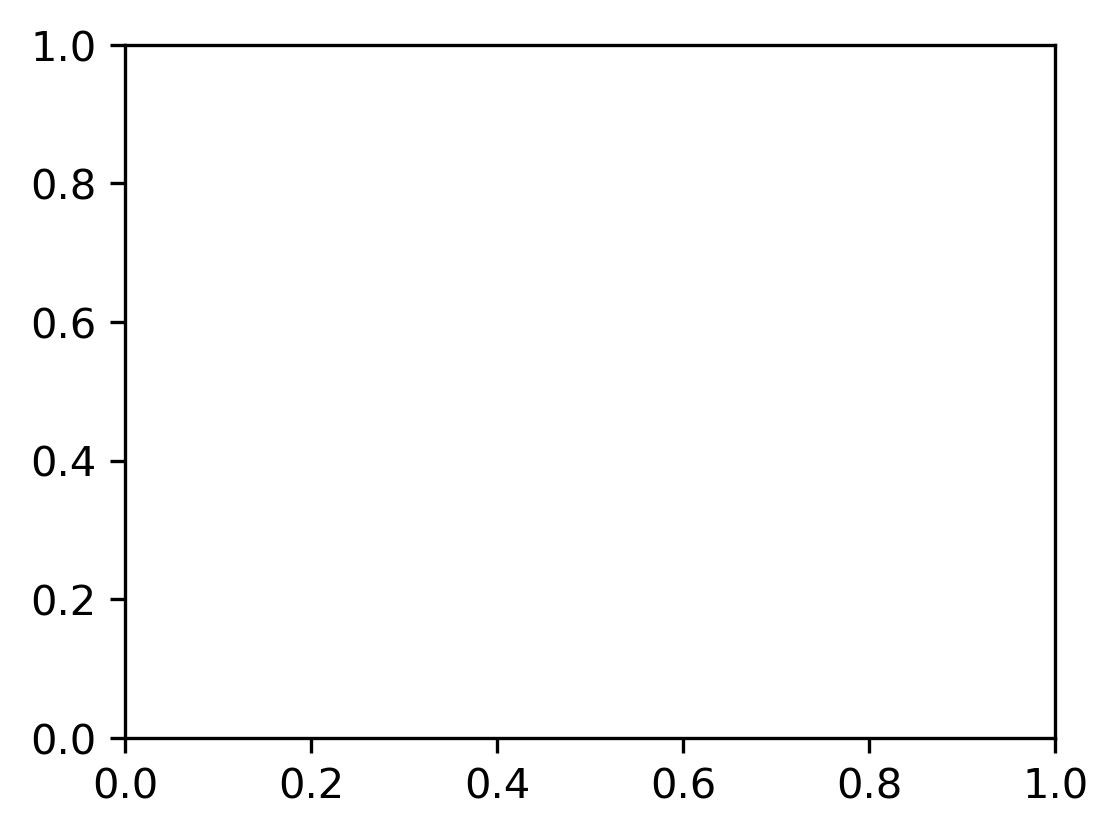

In [27]:

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_values, ax=ax, kde=True, bins=30, label='corr')
sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# # Add legend
# ax.legend()

# Show or save the figure
fig.savefig(f'./figures/0513_cluster_5_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


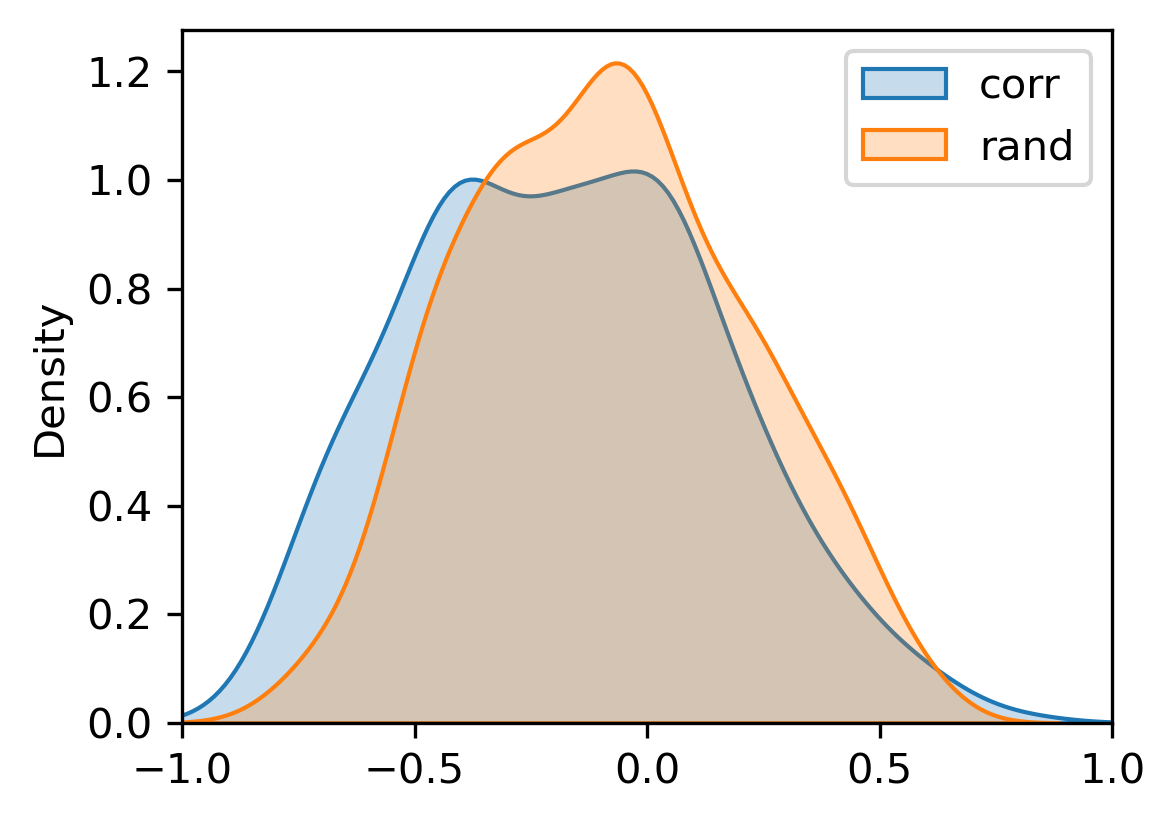

In [34]:

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.kdeplot(corr_values, ax=ax,fill=True, label='corr')
sns.kdeplot(rand_corr_values, ax=ax, fill=True, label='rand')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'./figures/0517_BW_kde_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


In [100]:
# encapsulate procedure in method for automation 

In [33]:
def plot_corr(cluster):
    dmgs = pd.read_csv(f'../../clusters/cluster{cluster}_genes.txt', header = None)
    dmgs_list = dmgs[0].tolist()
    
    # Subset the original DataFrame to include only the columns for the significant genes
    dmgs_overlap_df = mCGN_frac_by_cluster.loc[:, mCGN_frac_by_cluster.columns.isin(dmgs_list)]

    corr_values = dmgs_overlap_df.corrwith(rna_by_cluster, axis =0).dropna()
    
    columns = list(dmgs_overlap_df.columns)
    shuffled_columns = np.random.permutation(columns)
    shuffled_df = pd.DataFrame({columns[i]: df[shuffled_columns[i]].values for i in range(len(columns))})

    rand_corr_values = shuffled_df.corrwith(rna_by_cluster, axis =0).dropna()

    
    fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
    
    # Plot the histogram with KDE
    sns.histplot(corr_values, ax=ax, kde=True, bins=30, label='corr')
    sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')
    
    ax.set_xlim(-1, 1)
    fig.savefig(f'./figures/0517_kde_BW_mc_rna_correlation_with_shuffled.pdf', bbox_inches='tight')
    plt.show()


In [35]:
plot_corr(6)

KeyError: 'AT5G62610'

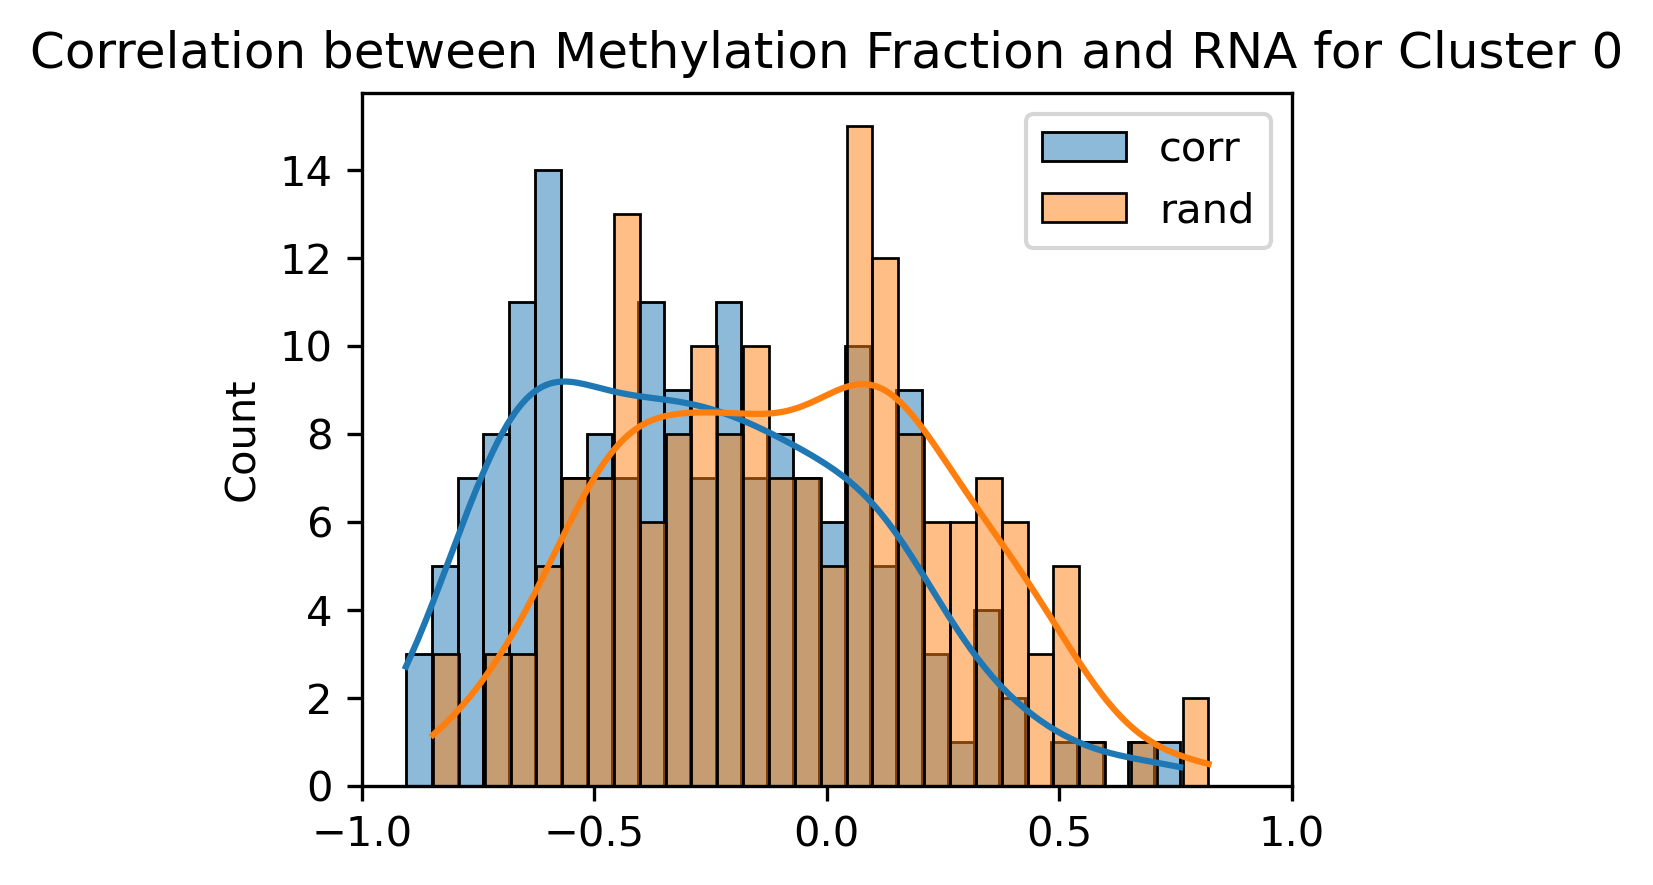

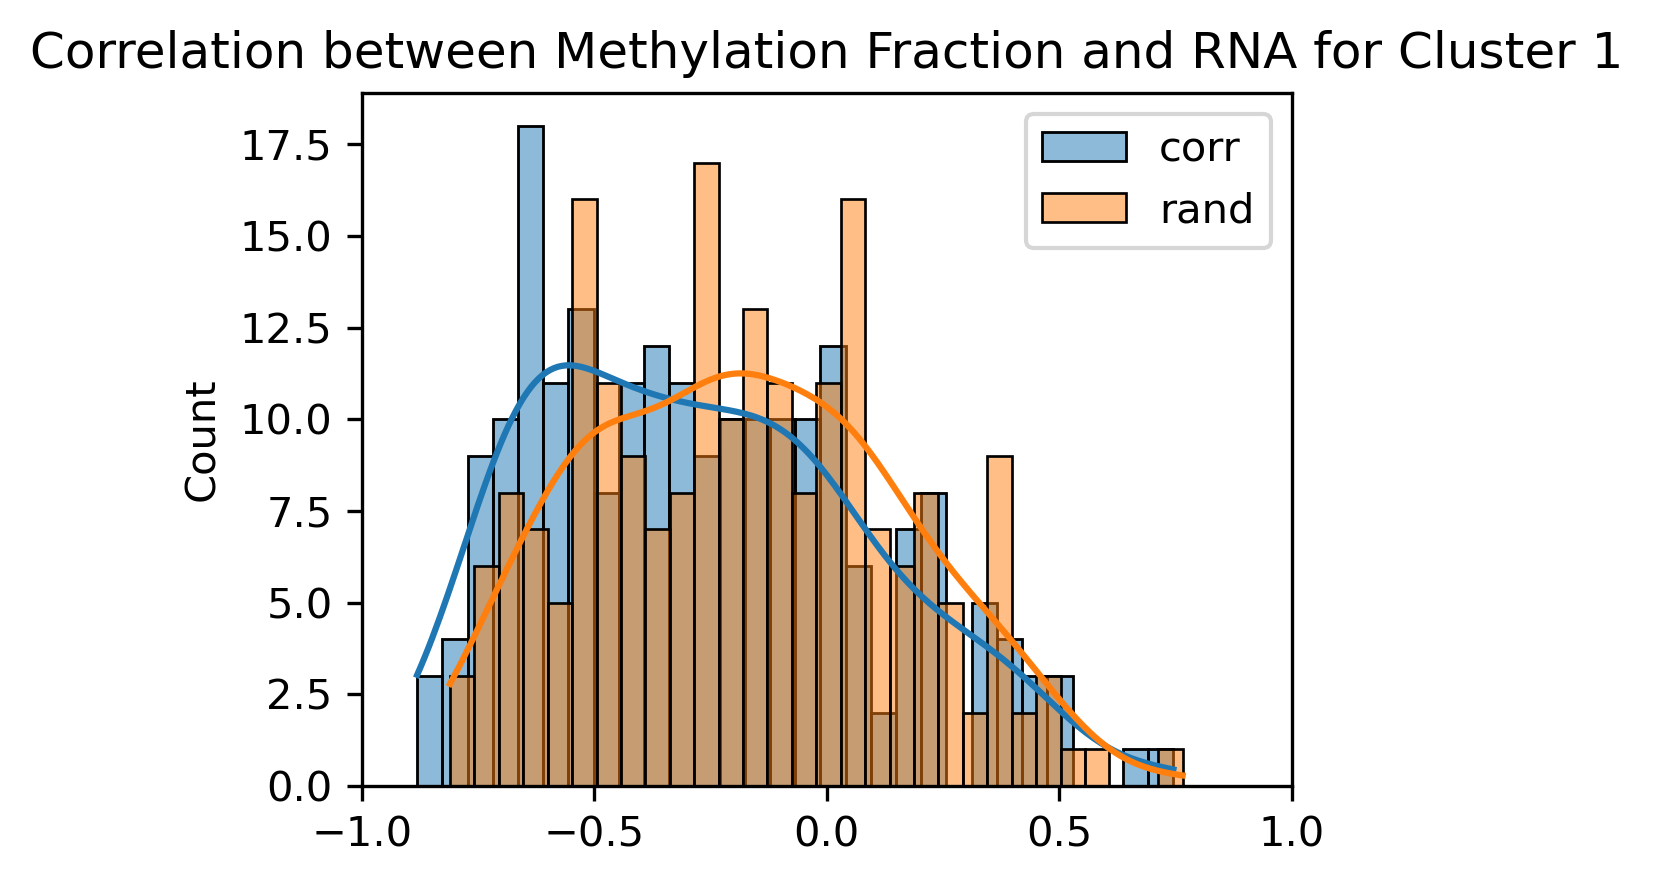

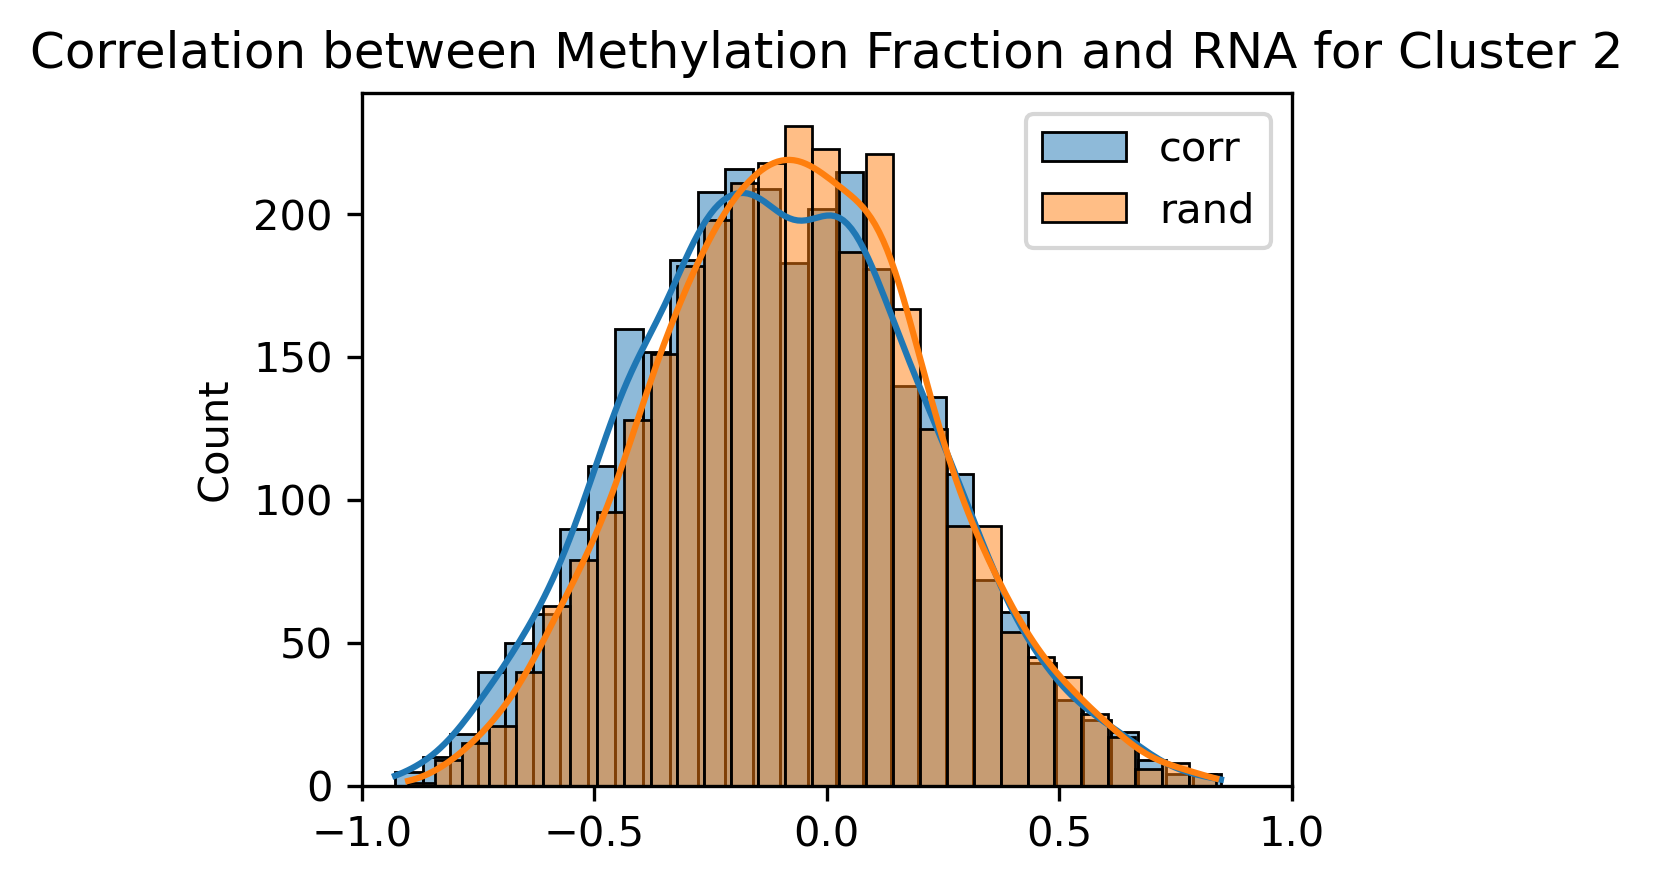

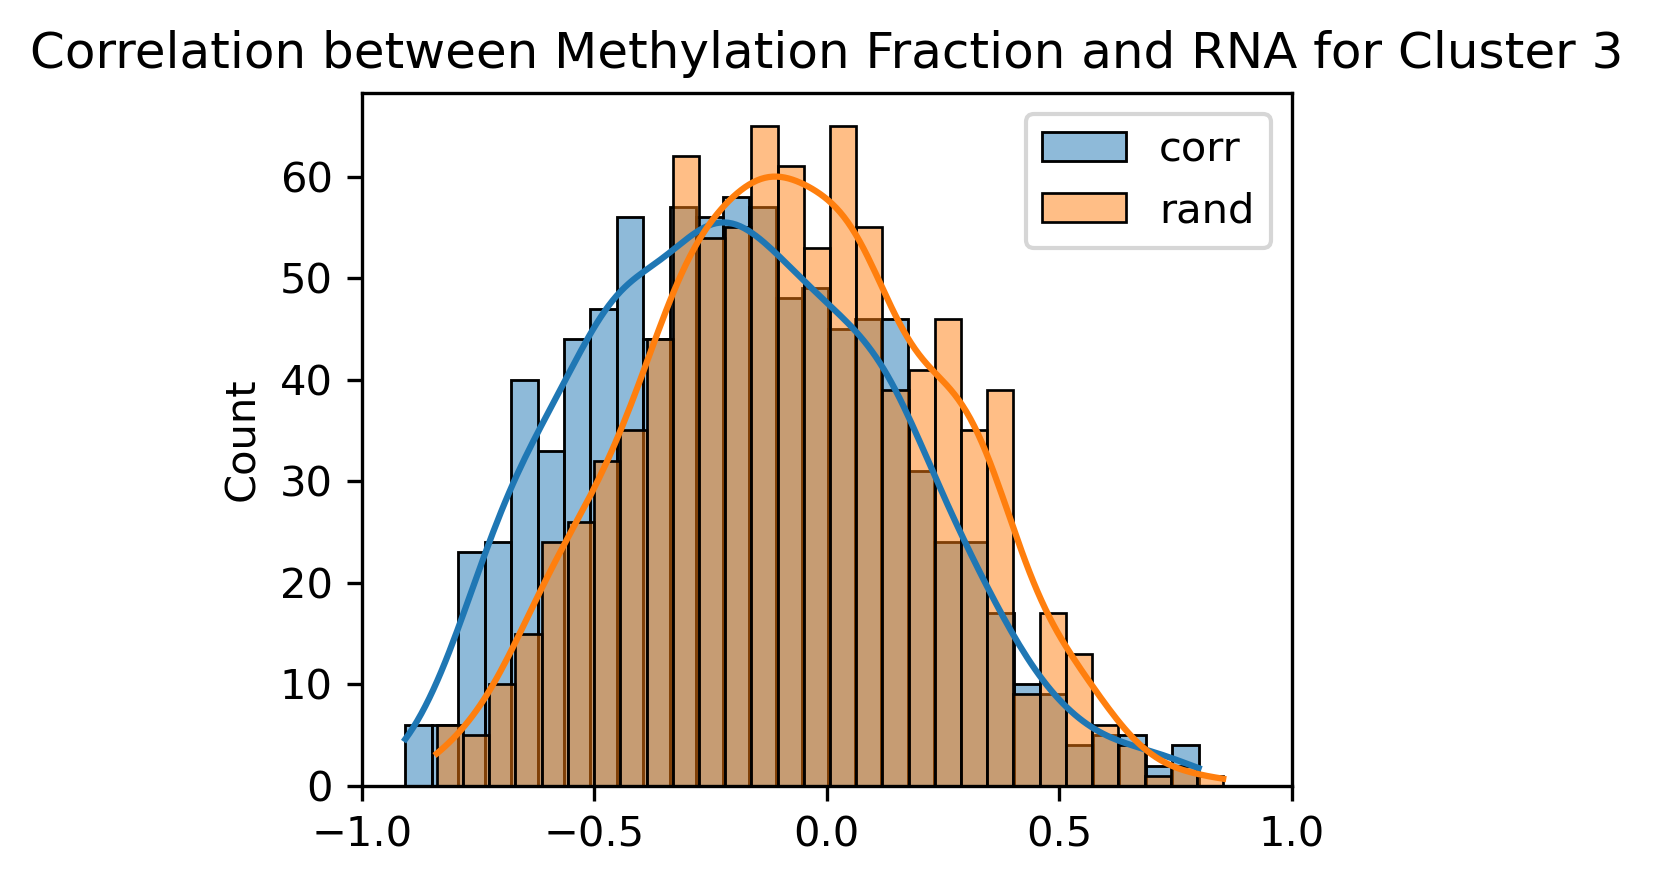

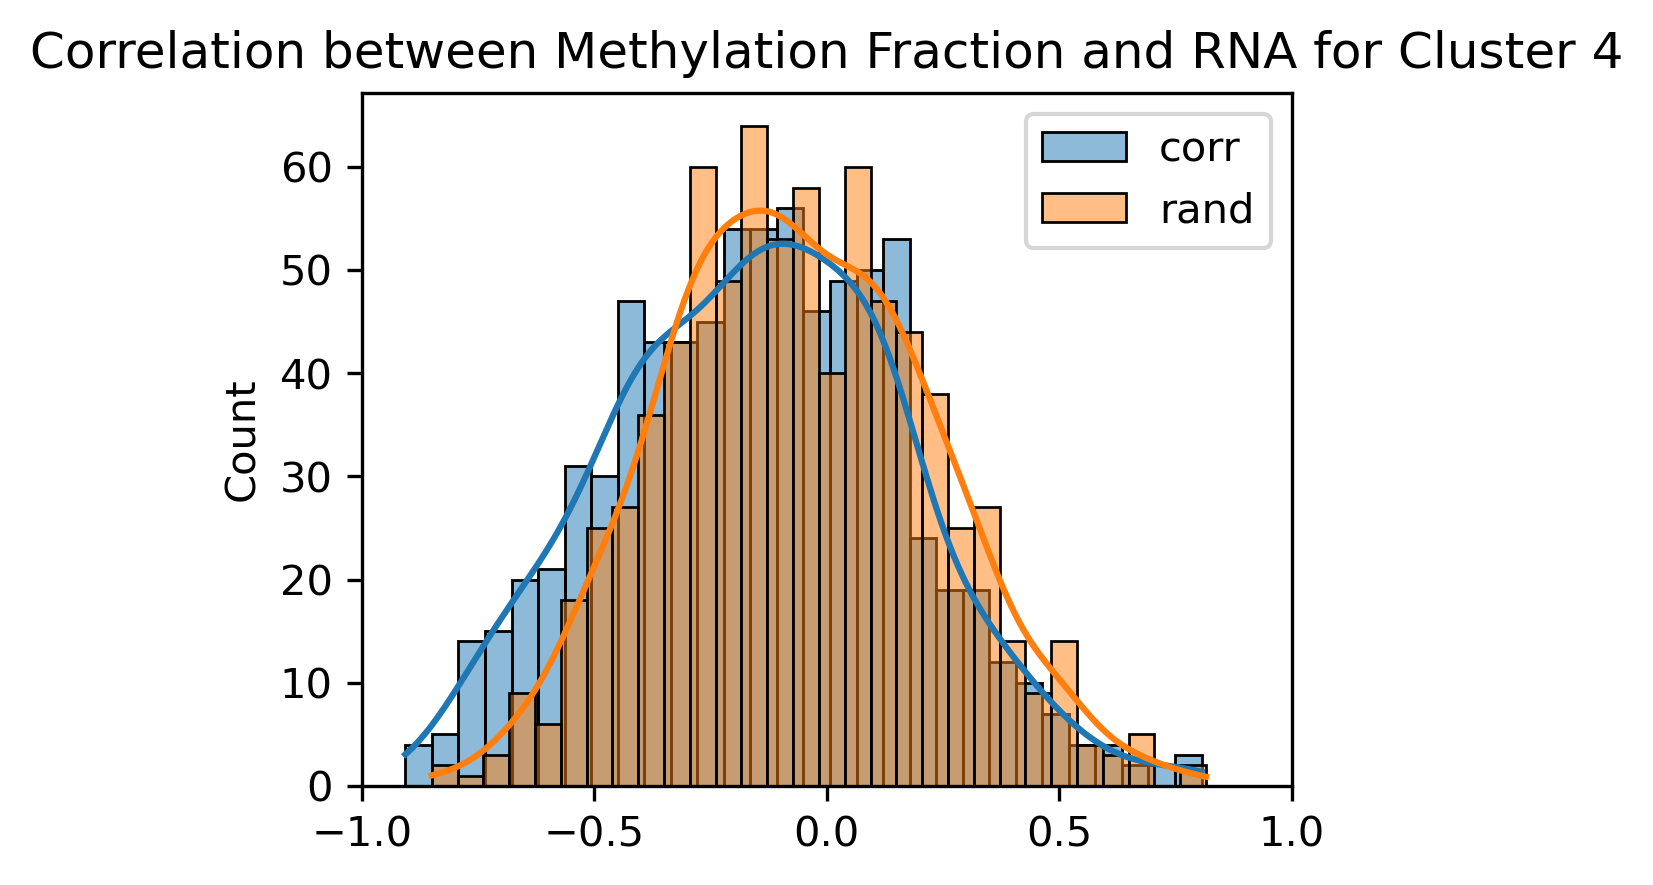

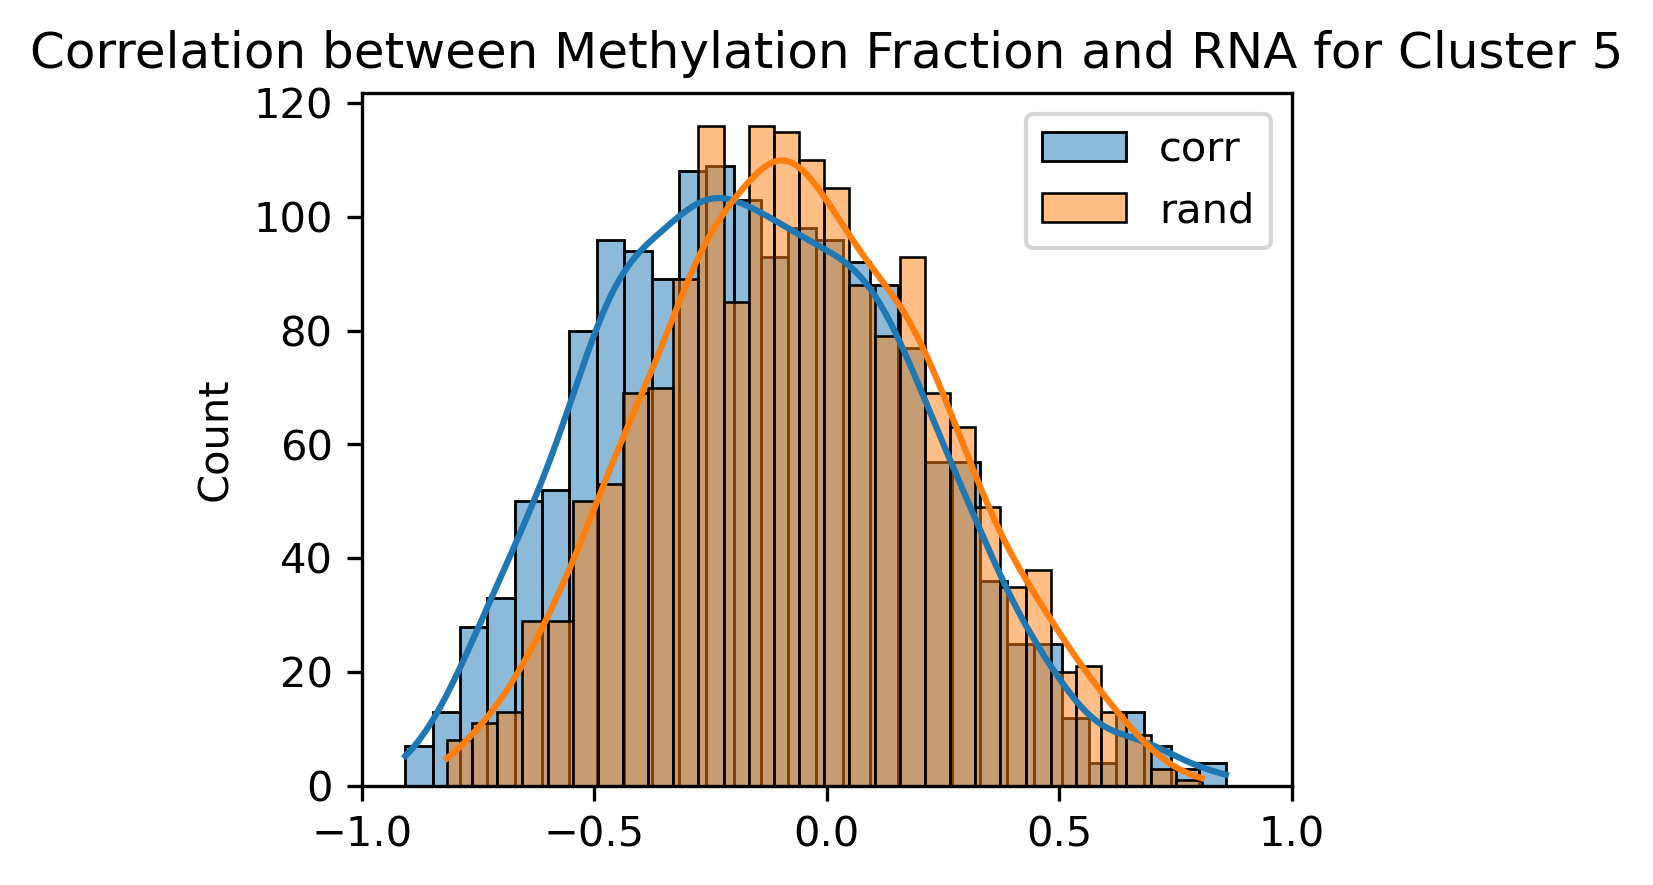

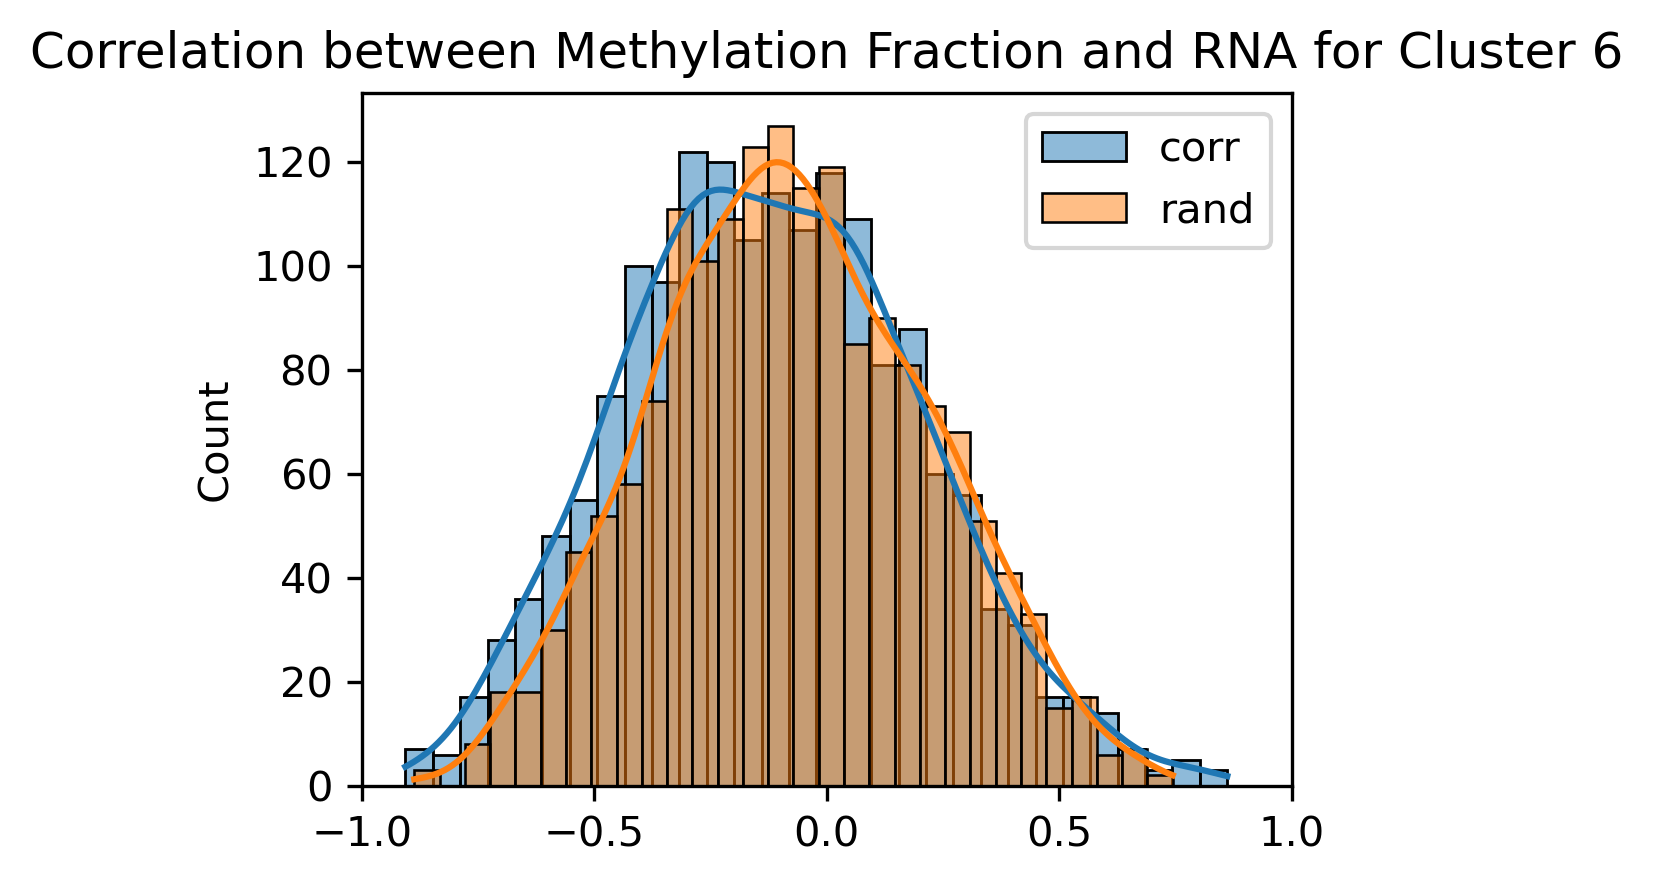

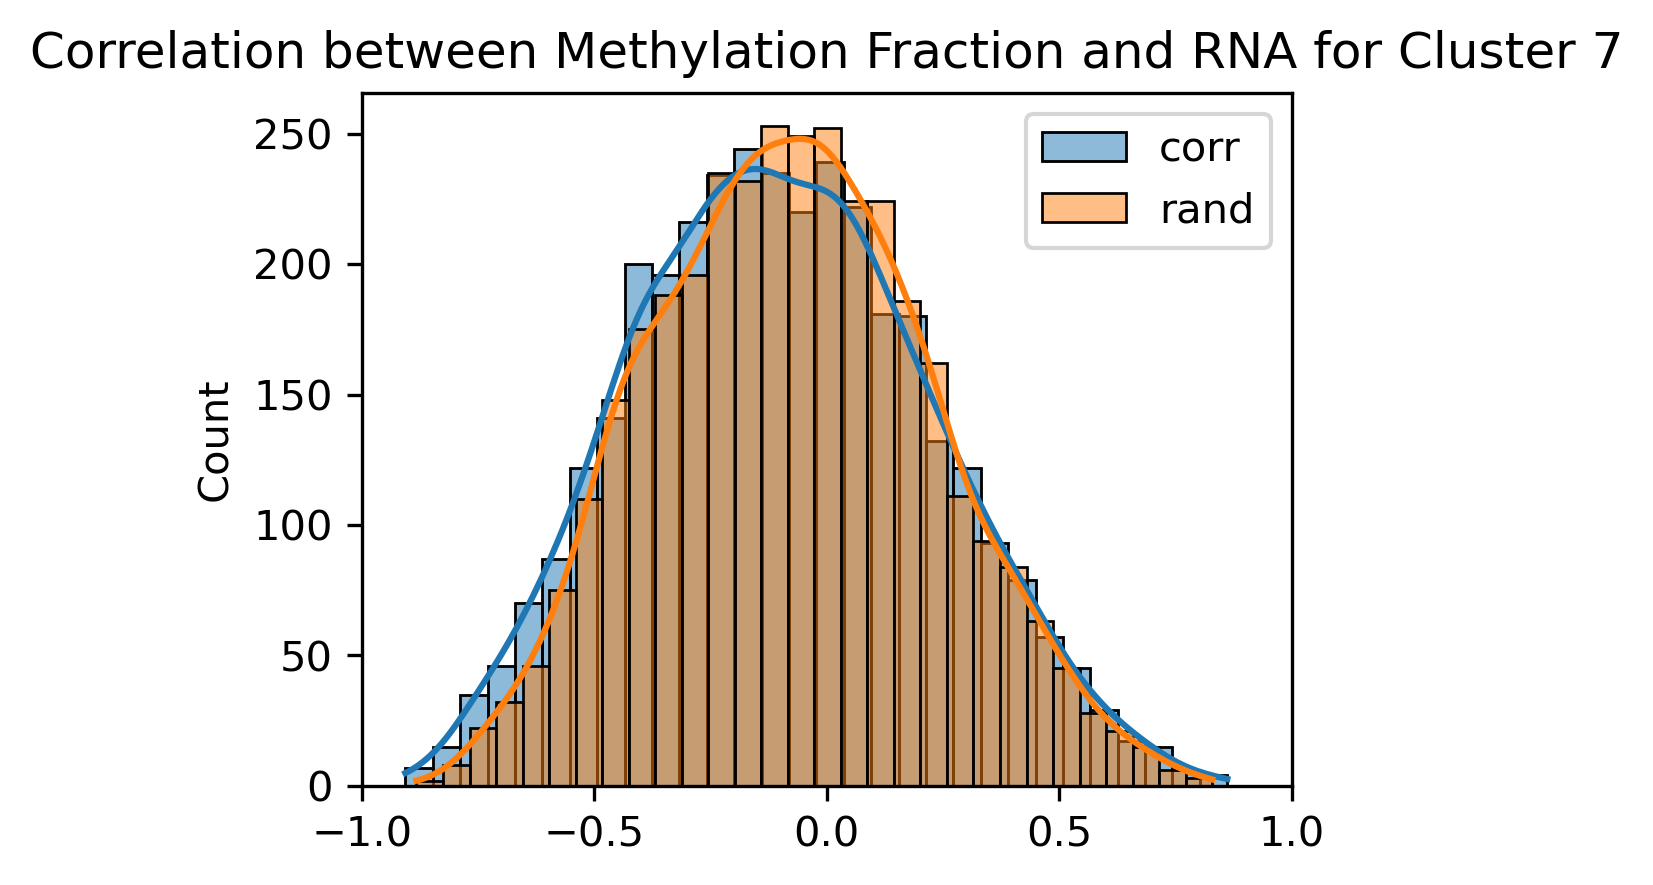

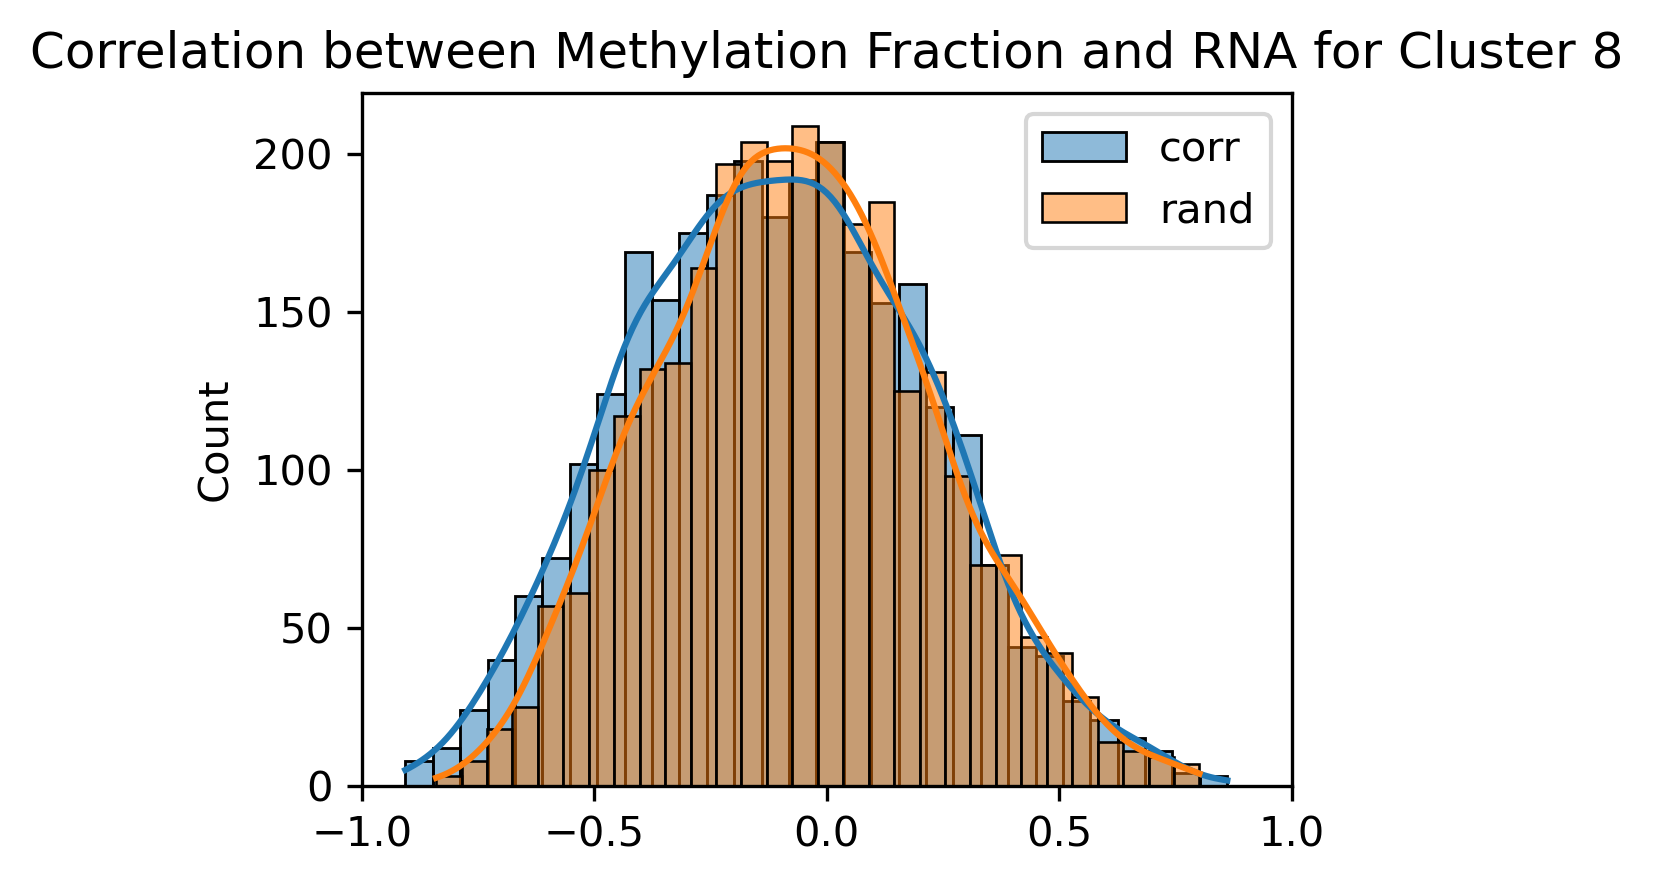

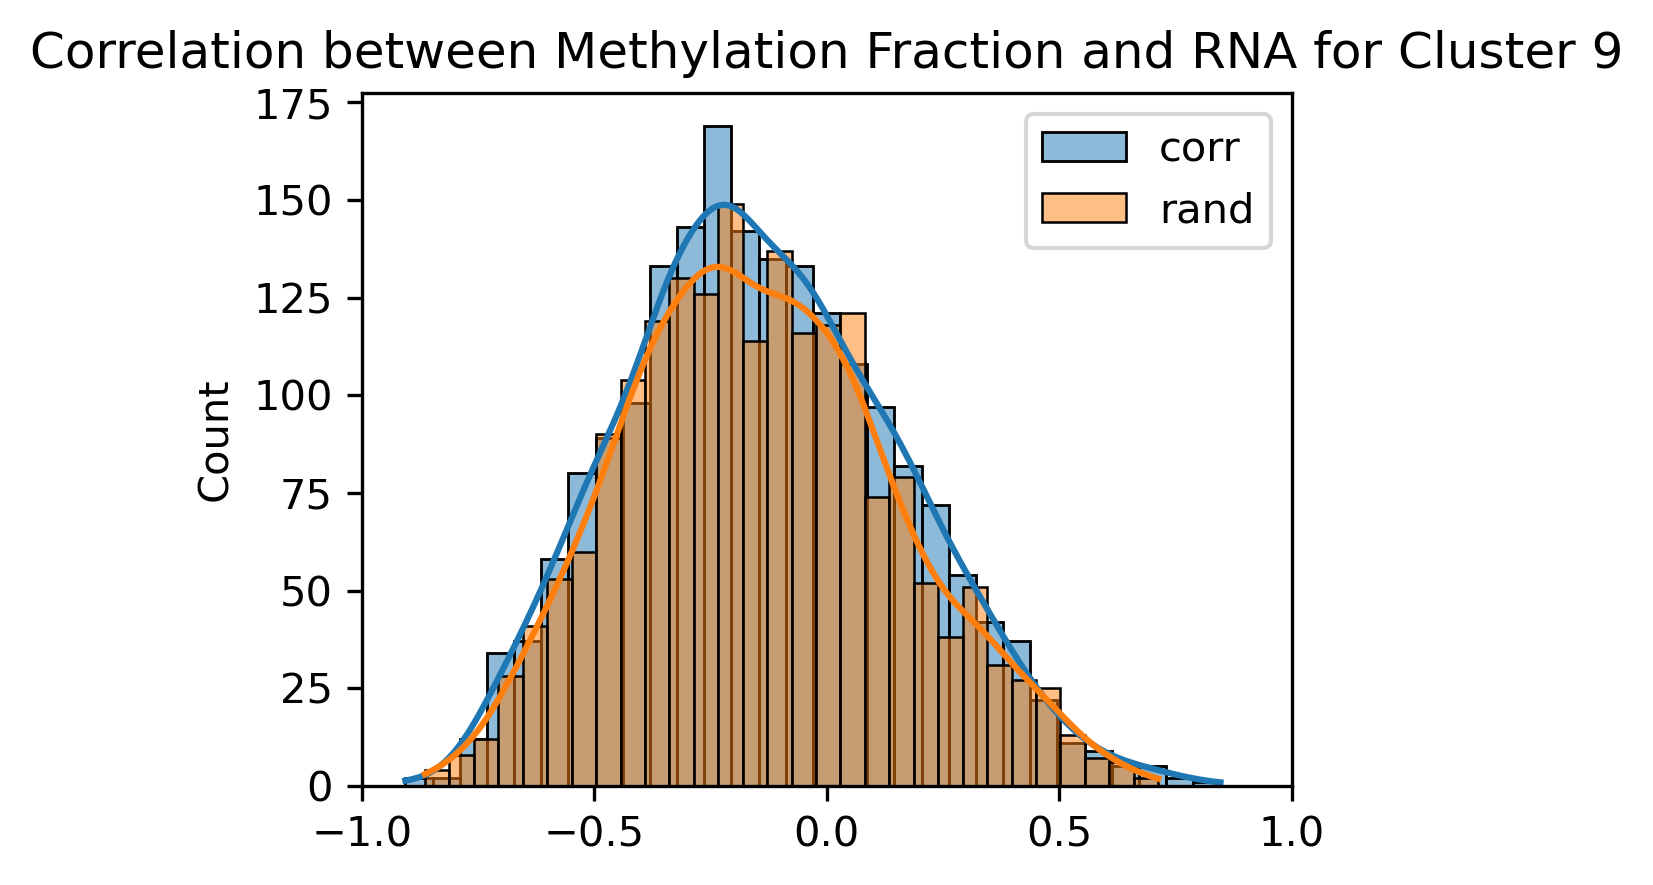

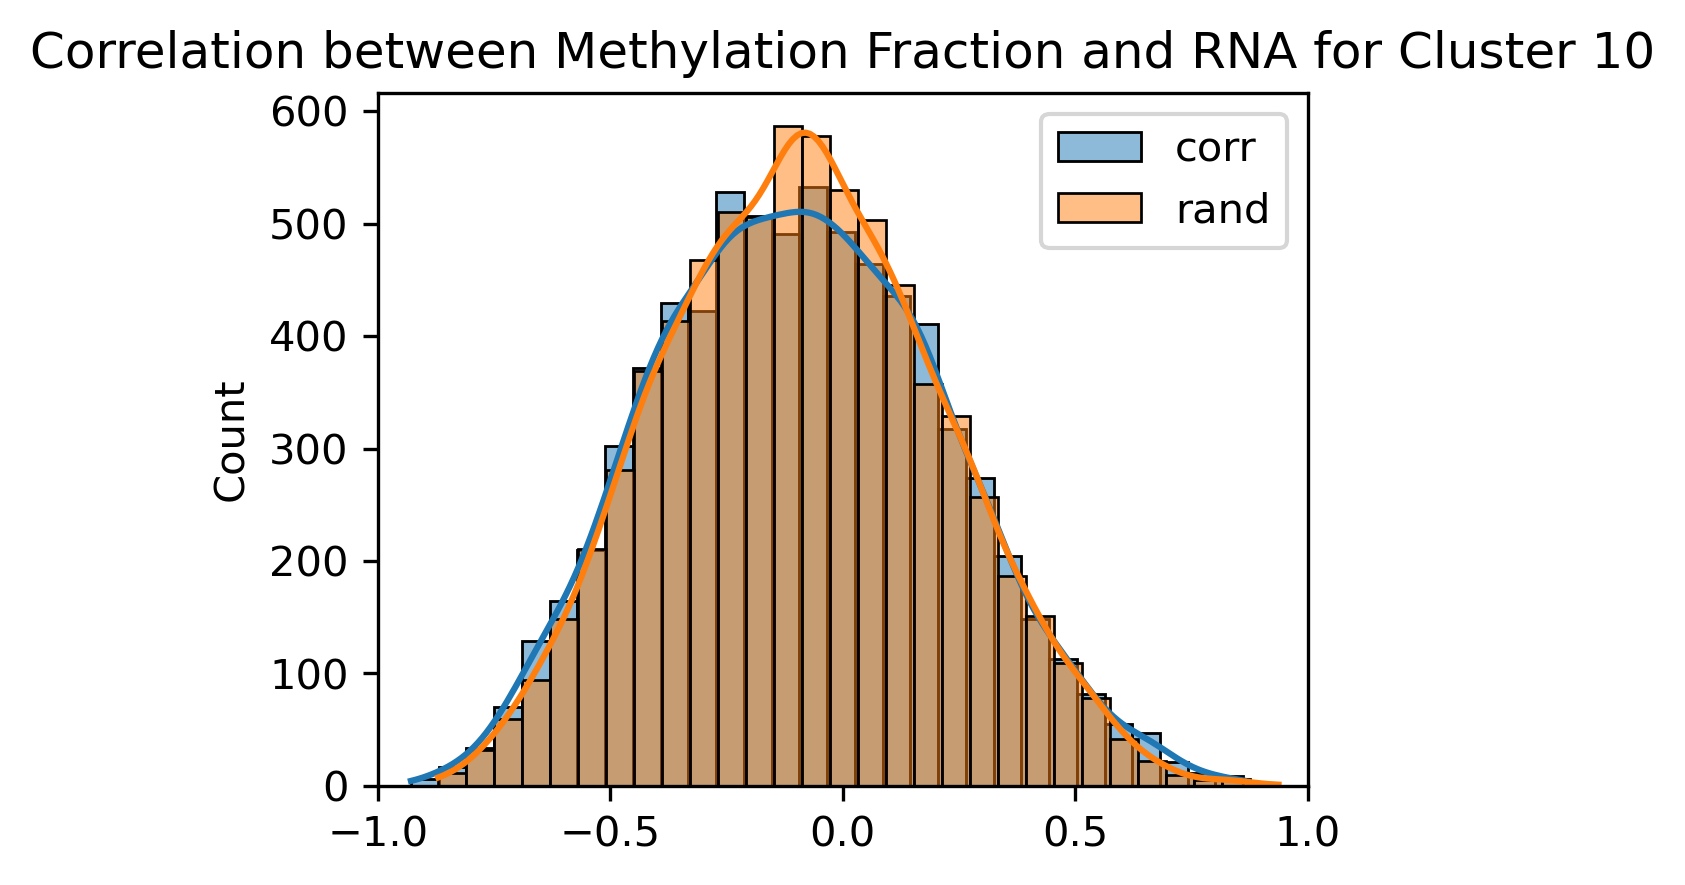

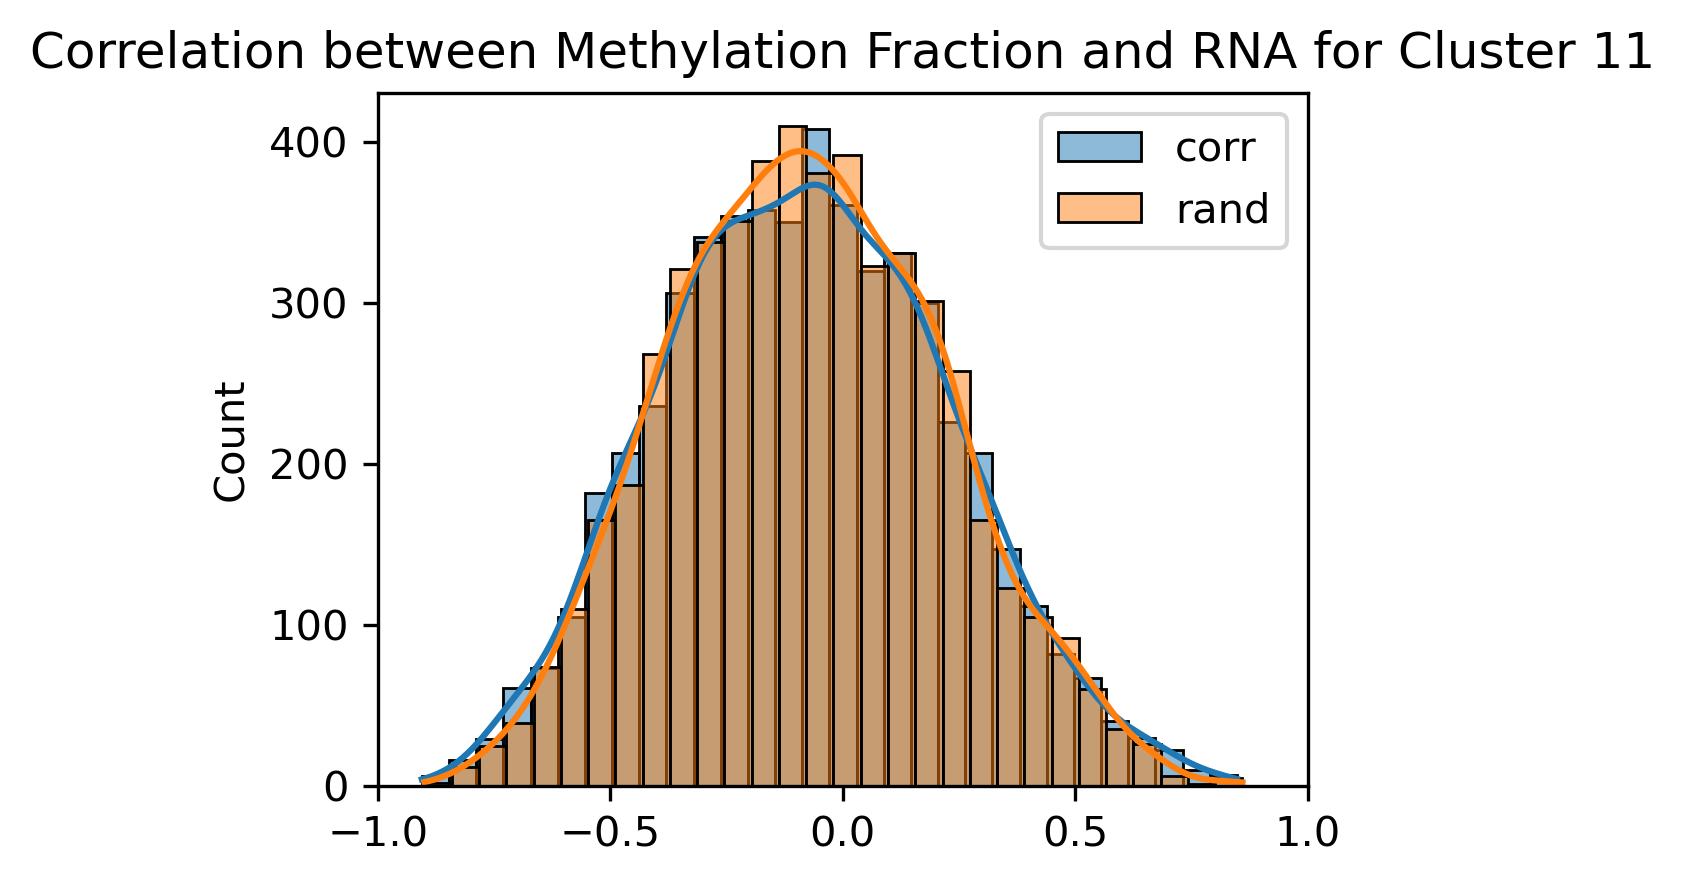

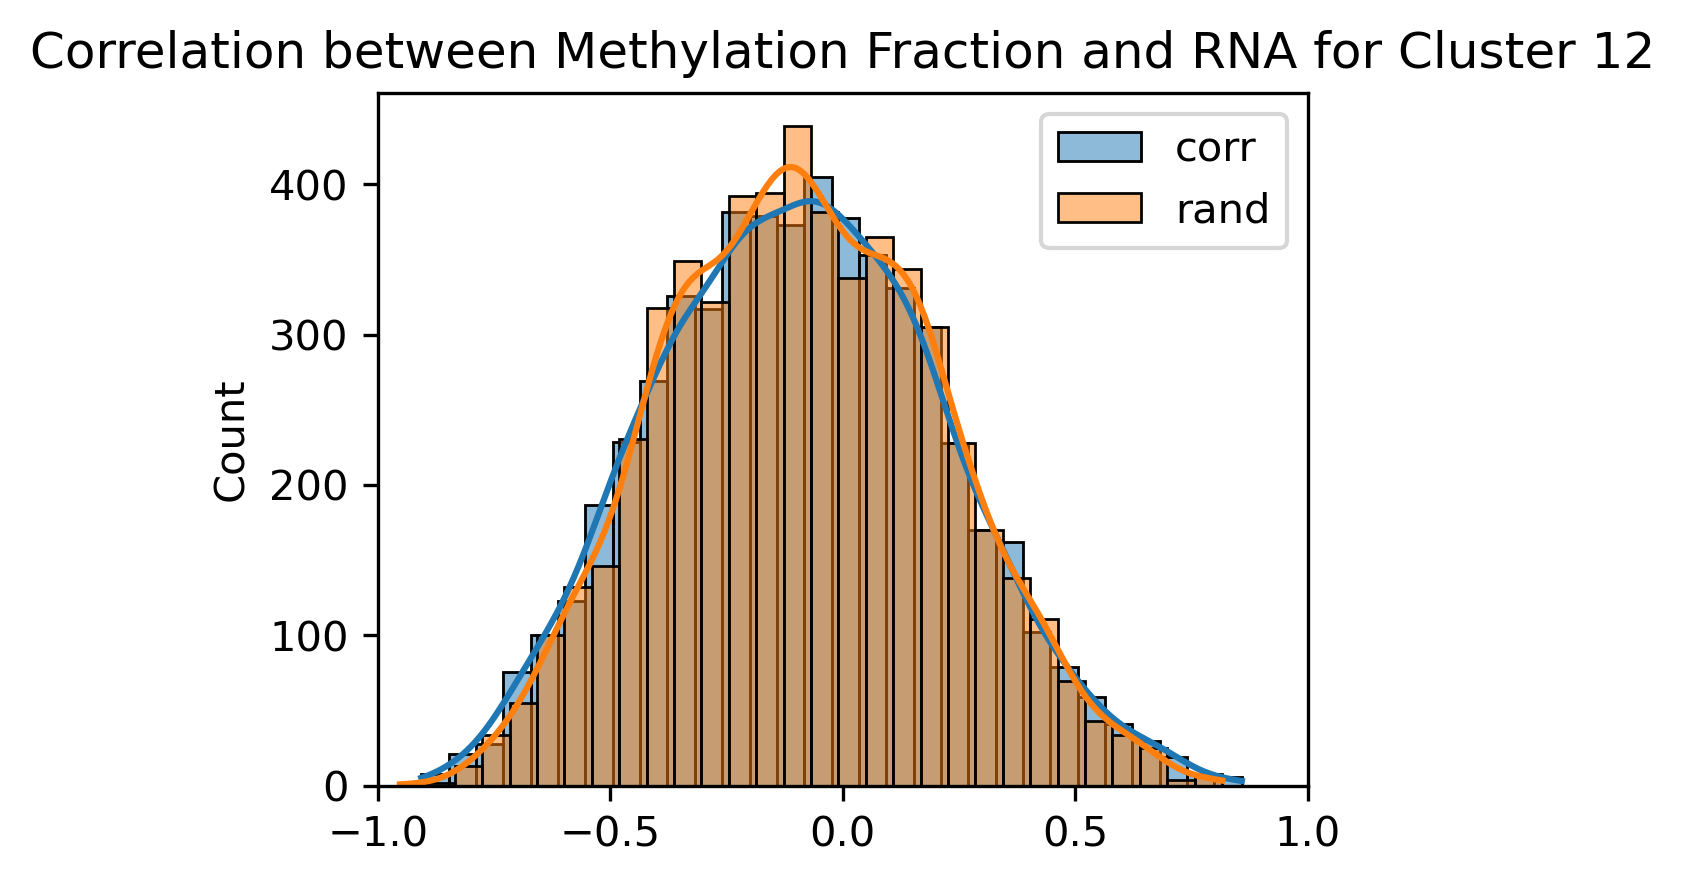

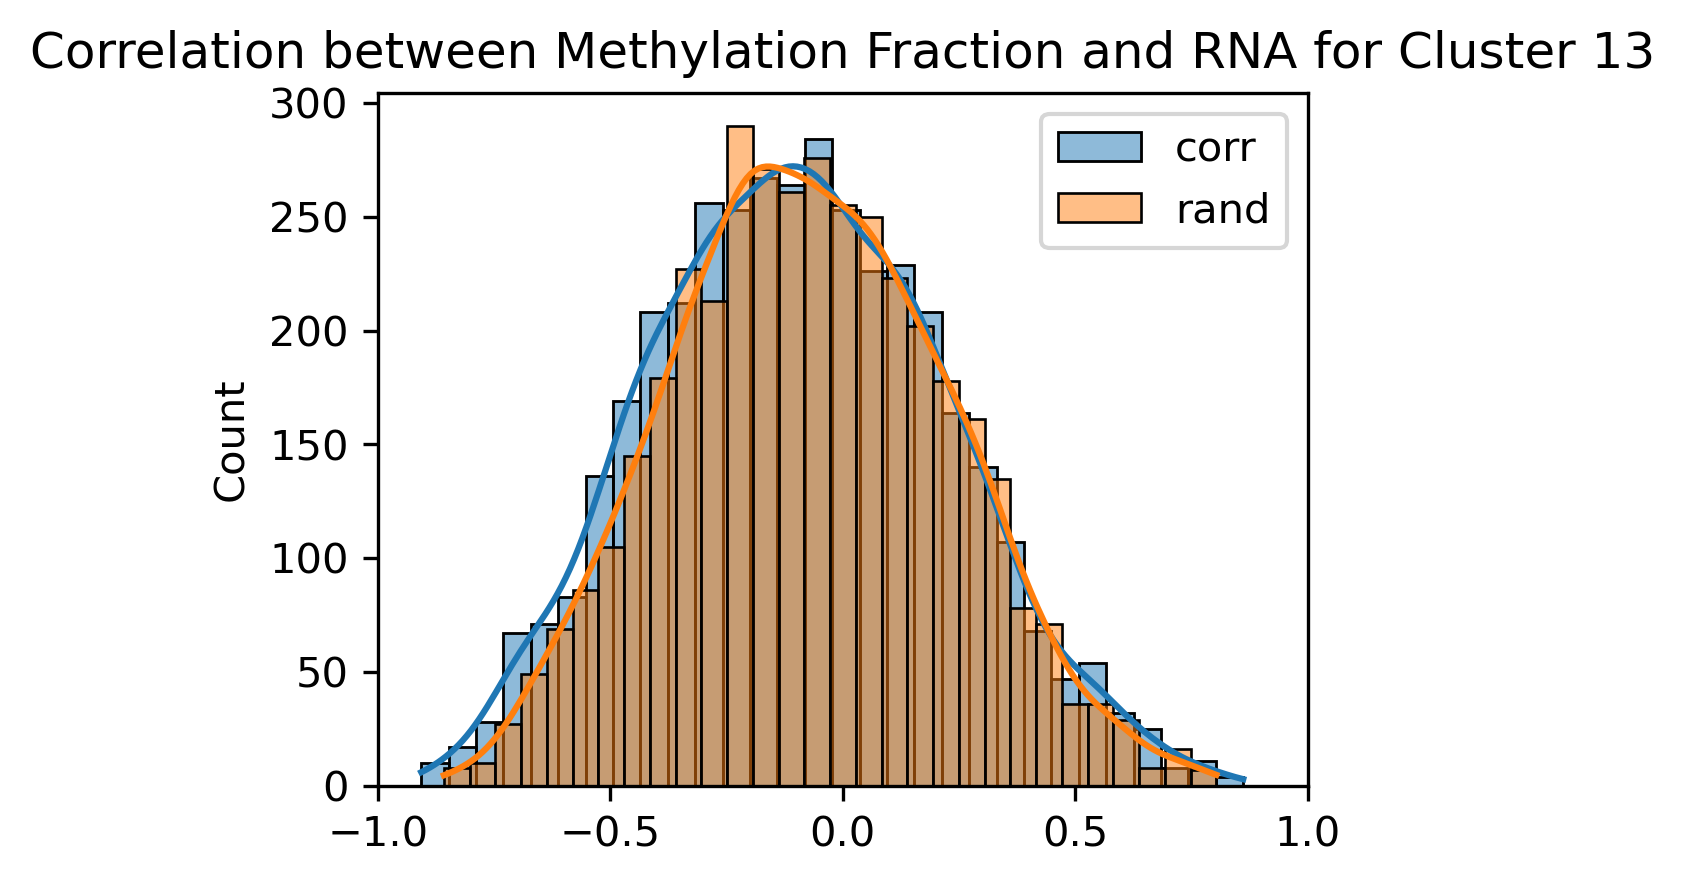

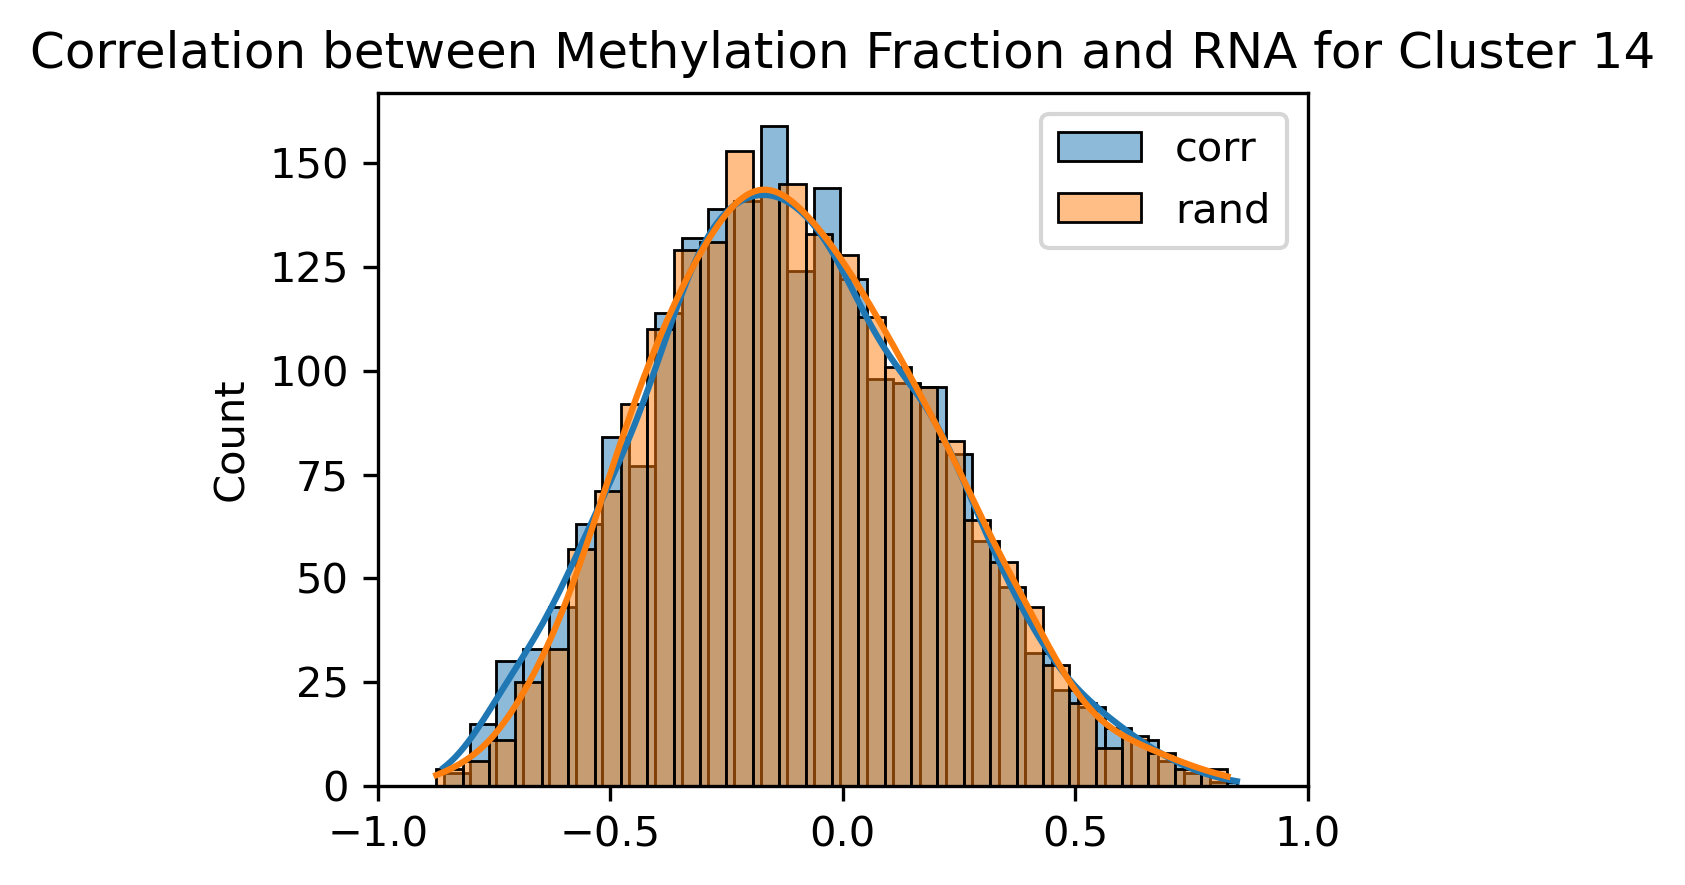

In [116]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_corr(cluster, mCGN_frac_by_cluster, rna_by_cluster, base_path='../../clusters', output_dir='./figures'):
    """
    Plot the correlation of methylation fraction with RNA by cluster, and compare with shuffled data.

    Parameters:
    cluster (int): The cluster number of interest to filter.
    mCGN_frac_by_cluster (pd.DataFrame): The DataFrame containing methylation fraction data.
    rna_by_cluster (pd.Series): The Series containing RNA data.
    base_path (str): Base path to the cluster gene files.
    output_dir (str): Directory to save the output plots.
    """
    # Load significant genes for the specified cluster
    dmgs = pd.read_csv(f'{base_path}/cluster{cluster}_genes.txt', header=None)
    dmgs_list = dmgs[0].tolist()
    
    # Subset the original DataFrame to include only the columns for the significant genes
    dmgs_overlap_df = mCGN_frac_by_cluster.loc[:, mCGN_frac_by_cluster.columns.isin(dmgs_list)]
    
    # Calculate correlation values
    corr_values = dmgs_overlap_df.corrwith(rna_by_cluster, axis=0).dropna()
    
    # Shuffle columns for random correlation calculation
    columns = list(dmgs_overlap_df.columns)
    shuffled_columns = np.random.permutation(columns)
    shuffled_df = pd.DataFrame({columns[i]: dmgs_overlap_df[shuffled_columns[i]].values for i in range(len(columns))})
    
    rand_corr_values = shuffled_df.corrwith(rna_by_cluster, axis=0).dropna()

    # Create the plot
    fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
    
    # Plot the histogram with KDE
    sns.histplot(corr_values, ax=ax, kde=True, bins=30, label='corr')
    sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')
    
    # Set x-axis limits
    ax.set_xlim(-1, 1)

    ax.set_title(f'Correlation between Methylation Fraction and RNA for Cluster {cluster}')
    
    # Add legend
    ax.legend()

    # Save the figure
    output_file = f'{output_dir}/0513_cluster_{cluster}_mc_rna_correlation_with_shuffled.pdf'
    fig.savefig(output_file, bbox_inches='tight')
    plt.show()

# # Example usage
# mCGN_frac_by_cluster = pd.read_csv('/path/to/mCGN_frac_by_cluster.csv')  # Replace with actual path
# rna_by_cluster = pd.read_csv('/path/to/rna_by_cluster.csv', index_col=0, squeeze=True)  # Replace with actual path

for i in range(15):
    plot_corr(i, mCGN_frac_by_cluster, rna_by_cluster)


In [118]:
pd.read_csv('../../clusters/cluster0_genes.txt',delimiter='tab')

/tmp/ipykernel_2764022/1409787122.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  pd.read_csv('../../clusters/cluster0_genes.txt',delimiter='tab')


,AT1G02110
0,AT1G03140
1,AT1G06730
2,AT1G09160
3,AT1G09995
4,AT1G11860
...,...
201,AT5G61070
202,AT5G65280
203,ATMG00030
204,ATMG00285


In [36]:
%ls ../../clusters

ALL.CG.above3.bed
ALL.CG.vs.cluster0.analysis.txt
ALL.CG.vs.cluster_0.bed
ALL.CG.vs.cluster0.bed
ALL.CG.vs.cluster0.methabove01.bed
ALL.CG.vs.cluster10.analysis.txt
ALL.CG.vs.cluster_10.bed
ALL.CG.vs.cluster10.bed
ALL.CG.vs.cluster10.methabove01.bed
ALL.CG.vs.cluster11.analysis.txt
ALL.CG.vs.cluster_11.bed
ALL.CG.vs.cluster11.bed
ALL.CG.vs.cluster11.methabove01.bed
ALL.CG.vs.cluster12.analysis.txt
ALL.CG.vs.cluster_12.bed
ALL.CG.vs.cluster12.bed
ALL.CG.vs.cluster12.methabove01.bed
ALL.CG.vs.cluster13.analysis.JW.txt
ALL.CG.vs.cluster13.analysis.txt
ALL.CG.vs.cluster_13.bed
ALL.CG.vs.cluster13.bed
ALL.CG.vs.cluster13.methabove01.bed
ALL.CG.vs.cluster14.analysis.txt
ALL.CG.vs.cluster_14.bed
ALL.CG.vs.cluster14.bed
ALL.CG.vs.cluster14.methabove01.bed
ALL.CG.vs.cluster1.analysis.txt
ALL.CG.vs.cluster_1.bed
ALL.CG.vs.cluster1.bed
ALL.CG.vs.cluster1.methabove01.bed
ALL.CG.vs.cluster2.analysis.txt
ALL.CG.vs.cluster_2.bed
ALL.CG.vs.cluster2.bed
ALL.CG.vs.cluster2.methabove01.bed
ALL.CG.vs.clus